# Fairness Audit and Explainability

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

import warnings

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
 
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

In [10]:
master  = pd.read_csv('../data/processed/county_master.csv')
results = pd.read_csv('../data/processed/model_results.csv')
 
print('master shape: ', master.shape)
print('results shape:', results.shape)
 
df = master.merge(results[['County', 'Predicted', 'Residual', 'Direction']],on='County')
 
print('Combined shape:', df.shape)
df.head()

master shape:  (47, 23)
results shape: (47, 6)
Combined shape: (47, 26)


,County,Total_beds,Total_facilities,closed,fully-functional,non-functional,semi-functional,Total_health_units,Pct_fully_functional,Pct_non_functional,...,Facility_reported_beds,Suspect_zero_bed_count,Population,Beds_per_10k,Facilities_per_10k,Pharmacies_per_10k,Infrastructure_score,Predicted,Residual,Direction
0,baringo,820,251,0,23,23,11,57,40.4,40.4,...,820.0,9,666763,12.30,3.76,2.73,0.208,0.208113,-0.000113,Overestimated
1,bomet,845,188,0,49,0,69,118,41.5,0.0,...,849.0,11,875689,9.65,2.15,1.40,0.173,0.178815,-0.005815,Overestimated
2,bungoma,2038,244,0,224,2,91,317,70.7,0.6,...,2038.0,3,1670570,12.20,1.46,0.74,0.317,0.317628,-0.000628,Overestimated
3,busia,1314,157,0,182,0,3,185,98.4,0.0,...,1314.0,2,893681,14.70,1.76,0.78,0.455,0.451479,0.003521,Underestimated
4,elgeyo-marakwet,858,134,0,11,32,19,62,17.7,51.6,...,858.0,15,454480,18.88,2.95,2.05,0.222,0.222258,-0.000258,Overestimated


In [11]:


region_map = {
    'nairobi':          'Nairobi',
    'mombasa':          'Coast',
    'kilifi':           'Coast',
    'kwale':            'Coast',
    'lamu':             'Coast',
    'taita taveta':     'Coast',
    'tana river':       'Coast',
    'kisumu':           'Nyanza',
    'homa bay':         'Nyanza',
    'migori':           'Nyanza',
    'kisii':            'Nyanza',
    'nyamira':          'Nyanza',
    'siaya':            'Nyanza',
    'kakamega':         'Western',
    'bungoma':          'Western',
    'busia':            'Western',
    'vihiga':           'Western',
    'uasin gishu':      'Rift Valley',
    'nakuru':           'Rift Valley',
    'kericho':          'Rift Valley',
    'bomet':            'Rift Valley',
    'nandi':            'Rift Valley',
    'baringo':          'Rift Valley',
    'laikipia':         'Rift Valley',
    'narok':            'Rift Valley',
    'kajiado':          'Rift Valley',
    'trans nzoia':      'Rift Valley',
    'west pokot':       'Rift Valley',
    'samburu':          'Rift Valley',
    'elgeyo-marakwet':  'Rift Valley',
    'turkana':          'Arid North',
    'marsabit':         'Arid North',
    'isiolo':           'Arid North',
    'mandera':          'Arid North',
    'wajir':            'Arid North',
    'garissa':          'Arid North',
    'kiambu':           'Central',
    "murang'a":         'Central',
    'kirinyaga':        'Central',
    'nyeri':            'Central',
    'nyandarua':        'Central',
    'meru':             'Eastern',
    'tharaka-nithi':    'Eastern',
    'embu':             'Eastern',
    'kitui':            'Eastern',
    'machakos':         'Eastern',
    'makueni':          'Eastern',
}
  
df['Region'] = df['County'].map(region_map)
 
unmatched = df[df['Region'].isnull()]['County'].tolist()

score_33 = df['Infrastructure_score'].quantile(0.33)
score_66 = df['Infrastructure_score'].quantile(0.66)
 
def assign_tier(score):
    if score <= score_33:
        return 'Bottom third'
    elif score <= score_66:
        return 'Middle third'
    else:
        return 'Top third'
 
df['Score_tier'] = df['Infrastructure_score'].apply(assign_tier)
 
print('\nRegion breakdown:')
print(df['Region'].value_counts())
 
print('\nScore tier breakdown:')
print(df['Score_tier'].value_counts())


Region breakdown:
Region
Rift Valley    13
Eastern         6
Arid North      6
Nyanza          6
Coast           6
Central         5
Western         4
Nairobi         1
Name: count, dtype: int64

Score tier breakdown:
Score_tier
Bottom third    16
Top third       16
Middle third    15
Name: count, dtype: int64


In [12]:
# Map counties to regions
region_map = {
    'nairobi':        'Nairobi',
    'mombasa':        'Coast',
    'kilifi':         'Coast',
    'kwale':          'Coast',
    'lamu':           'Coast',
    'taita taveta':   'Coast',
    'tana river':     'Coast',
    'kisumu':         'Nyanza',
    'homa bay':       'Nyanza',
    'migori':         'Nyanza',
    'kisii':          'Nyanza',
    'nyamira':        'Nyanza',
    'siaya':          'Nyanza',
    'kakamega':       'Western',
    'bungoma':        'Western',
    'busia':          'Western',
    'vihiga':         'Western',
    'uasin gishu':    'Rift Valley',
    'nakuru':         'Rift Valley',
    'kericho':        'Rift Valley',
    'bomet':          'Rift Valley',
    'nandi':          'Rift Valley',
    'baringo':        'Rift Valley',
    'laikipia':       'Rift Valley',
    'narok':          'Rift Valley',
    'kajiado':        'Rift Valley',
    'trans nzoia':    'Rift Valley',
    'west pokot':     'Rift Valley',
    'samburu':        'Rift Valley',
    'turkana':        'Arid North',
    'marsabit':       'Arid North',
    'isiolo':         'Arid North',
    'mandera':        'Arid North',
    'wajir':          'Arid North',
    'garissa':        'Arid North',
    'kiambu':         'Central',
    'murang\'a':      'Central',
    'kirinyaga':      'Central',
    'nyeri':          'Central',
    'nyandarua':      'Central',
    'meru':           'Eastern',
    'tharaka-nithi':  'Eastern',
    'embu':           'Eastern',
    'kitui':          'Eastern',
    'machakos':       'Eastern',
    'makueni':        'Eastern',
    'elgeyo-marakwet':'Rift Valley',
}
 
df['Region'] = df['County'].map(region_map)

In [13]:
def fairness_metrics(data, group_col):
    rows = []
    for group in sorted(data[group_col].unique()):
        subset        = data[data[group_col] == group]
        mae           = mean_absolute_error(subset['Infrastructure_score'], subset['Predicted'])
        mean_residual = subset['Residual'].mean()
        count         = len(subset)
        rows.append({
            'Group':          group,
            'Count':          count,
            'MAE':            round(mae, 5),
            'Mean_residual':  round(mean_residual, 5),
            'Bias_direction': 'Overestimated' if mean_residual < 0 else 'Underestimated'
        })
    return pd.DataFrame(rows).sort_values('MAE', ascending=False)
 
 
region_fairness = fairness_metrics(df, 'Region')
tier_fairness   = fairness_metrics(df, 'Score_tier')
 
print('Fairness by Region')
print(region_fairness.to_string(index=False))
 
print('\nFairness by Score Tier')
print(tier_fairness.to_string(index=False))

Fairness by Region
      Group  Count     MAE  Mean_residual Bias_direction
    Nairobi      1 0.00693        0.00693 Underestimated
    Eastern      6 0.00638       -0.00149  Overestimated
     Nyanza      6 0.00431        0.00431 Underestimated
Rift Valley     13 0.00201       -0.00044  Overestimated
    Central      5 0.00179       -0.00157  Overestimated
      Coast      6 0.00162       -0.00134  Overestimated
    Western      4 0.00157        0.00019 Underestimated
 Arid North      6 0.00148        0.00018 Underestimated

Fairness by Score Tier
       Group  Count     MAE  Mean_residual Bias_direction
   Top third     16 0.00378        0.00366 Underestimated
Bottom third     16 0.00291       -0.00282  Overestimated
Middle third     15 0.00160       -0.00062  Overestimated


In [14]:
def group_fairness_metrics(data, group_col):
    results_list = []
    for group in data[group_col].unique():
        subset = data[data[group_col] == group]
        mae  = mean_absolute_error(subset['Infrastructure_score'], subset['Predicted'])
        mean_residual = subset['Residual'].mean()
        count = len(subset)
        results_list.append({
            'Group':          group,
            'Count':          count,
            'MAE':            round(mae, 5),
            'Mean_residual':  round(mean_residual, 5),
            'Bias_direction': 'Overestimated' if mean_residual < 0 else 'Underestimated'
        })
    return pd.DataFrame(results_list).sort_values('MAE', ascending=False)
 
region_fairness = group_fairness_metrics(df, 'Region')
tier_fairness   = group_fairness_metrics(df, 'Score_tier')
 
print('Fairness by Region')
print(region_fairness.to_string(index=False))
print()
print('Fairness by Score Tier')
print(tier_fairness.to_string(index=False))

Fairness by Region
      Group  Count     MAE  Mean_residual Bias_direction
    Nairobi      1 0.00693        0.00693 Underestimated
    Eastern      6 0.00638       -0.00149  Overestimated
     Nyanza      6 0.00431        0.00431 Underestimated
Rift Valley     13 0.00201       -0.00044  Overestimated
    Central      5 0.00179       -0.00157  Overestimated
      Coast      6 0.00162       -0.00134  Overestimated
    Western      4 0.00157        0.00019 Underestimated
 Arid North      6 0.00148        0.00018 Underestimated

Fairness by Score Tier
       Group  Count     MAE  Mean_residual Bias_direction
   Top third     16 0.00378        0.00366 Underestimated
Bottom third     16 0.00291       -0.00282  Overestimated
Middle third     15 0.00160       -0.00062  Overestimated


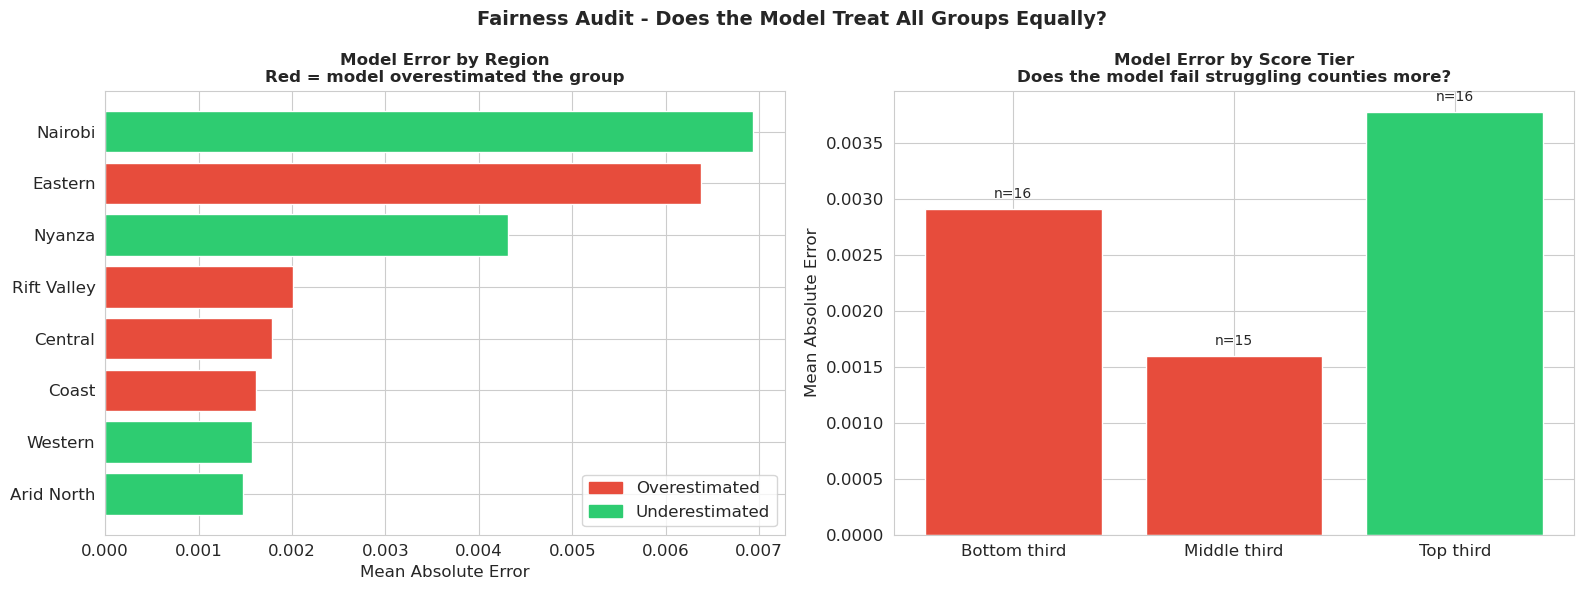

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Fairness by Region 
region_sorted = region_fairness.sort_values('MAE', ascending=True)
bar_colors    = ['#e74c3c' if b == 'Overestimated' else '#2ecc71'
                 for b in region_sorted['Bias_direction']]
 
axes[0].barh(region_sorted['Group'], region_sorted['MAE'],
             color=bar_colors, edgecolor='white')
axes[0].set_title('Model Error by Region\nRed = model overestimated the group',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Absolute Error') 
red_patch   = mpatches.Patch(color='#e74c3c', label='Overestimated')
green_patch = mpatches.Patch(color='#2ecc71', label='Underestimated')
axes[0].legend(handles=[red_patch, green_patch])
 
# Plot 2: Fairness by Score Tier 
tier_order  = ['Bottom third', 'Middle third', 'Top third']
tier_sorted = tier_fairness.set_index('Group').loc[tier_order].reset_index()
tier_colors = ['#e74c3c' if b == 'Overestimated' else '#2ecc71'
               for b in tier_sorted['Bias_direction']]
 
axes[1].bar(tier_sorted['Group'], tier_sorted['MAE'],
            color=tier_colors, edgecolor='white')
axes[1].set_title('Model Error by Score Tier\nDoes the model fail struggling counties more?',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error')
 
for i, row in tier_sorted.iterrows():
    axes[1].text(i, row['MAE'] + 0.0001,
                 f"n={row['Count']}", ha='center', fontsize=10)
 
plt.suptitle('Fairness Audit: Does the Model Treat All Groups Equally?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fairness_by_group.png', dpi=150)
plt.show()

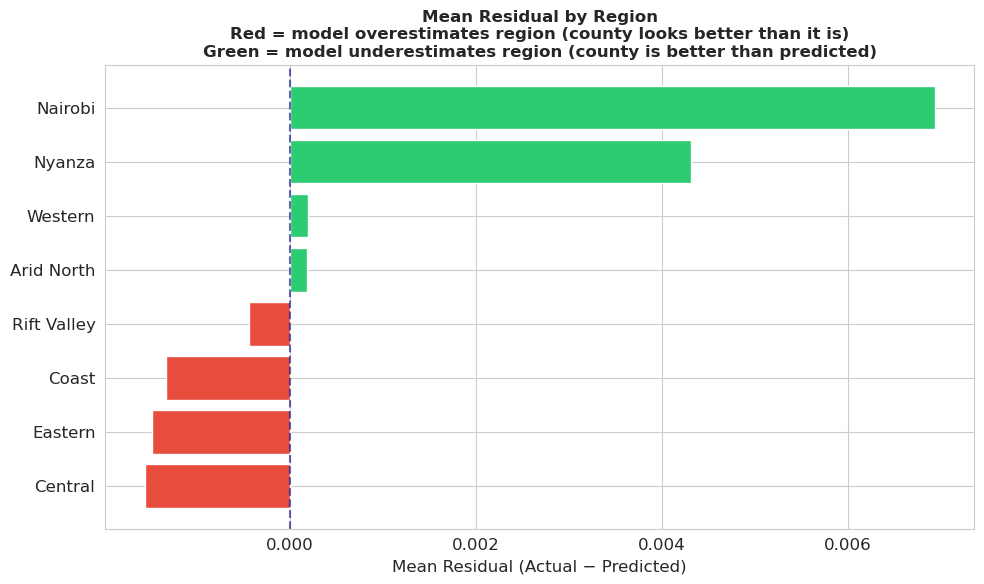

In [16]:
region_residuals = (
    df.groupby('Region')['Residual']
    .mean()
    .reset_index()
    .sort_values('Residual')
)
  
colors = ['#e74c3c' if r < 0 else '#2ecc71' for r in region_residuals['Residual']]
 
plt.figure(figsize=(10, 6))
plt.barh(region_residuals['Region'], region_residuals['Residual'],
         color=colors, edgecolor='white')
plt.axvline(x=0, color='navy', linestyle='--', alpha=0.6)
plt.title('Mean Residual by Region\n'
          'Red = model overestimates region (county looks better than it is)\n'
          'Green = model underestimates region (county is better than predicted)',
          fontsize=12, fontweight='bold')
plt.xlabel('Mean Residual (Actual − Predicted)')
plt.tight_layout()
plt.savefig('../outputs/figures/mean_residual_by_region.png', dpi=150)
plt.show()

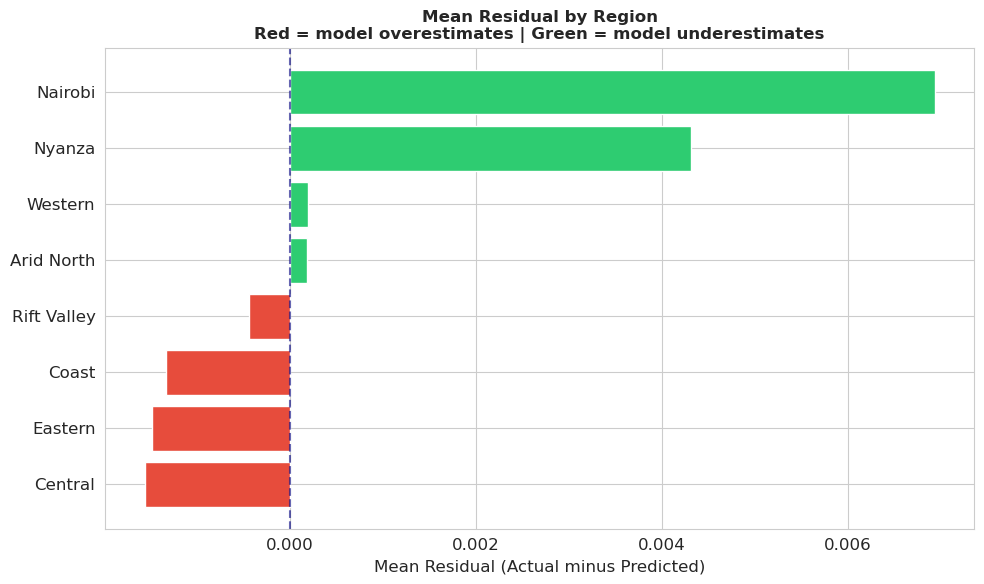

In [17]:
region_residuals = (
    df.groupby('Region')['Residual']
    .mean()
    .reset_index()
    .sort_values('Residual')
)
 
bar_colors = ['#e74c3c' if r < 0 else '#2ecc71'
              for r in region_residuals['Residual']]
 
plt.figure(figsize=(10, 6))
plt.barh(region_residuals['Region'], region_residuals['Residual'],
         color=bar_colors, edgecolor='white')
plt.axvline(x=0, color='navy', linestyle='--', alpha=0.6)
plt.title('Mean Residual by Region\n'
          'Red = model overestimates | Green = model underestimates',
          fontsize=12, fontweight='bold')
plt.xlabel('Mean Residual (Actual minus Predicted)')
plt.tight_layout()
plt.savefig('../outputs/figures/mean_residual_by_region.png', dpi=150)
plt.show()
 

SHAP values shape: (47, 7)
Rows = counties, Columns = features
SHAP values saved.


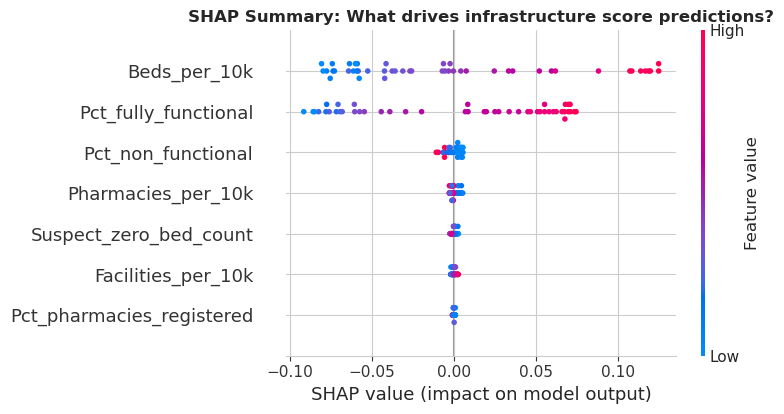

In [23]:


features = [
    'Beds_per_10k',
    'Facilities_per_10k',
    'Pharmacies_per_10k',
    'Pct_fully_functional',
    'Pct_non_functional',
    'Pct_pharmacies_registered',
    'Suspect_zero_bed_count'
]
 
X = master[features].copy()
y = master['Infrastructure_score'].copy()
 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
  
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)
rf_model.fit(X_scaled, y)
 
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_scaled)
 
print('SHAP values shape:', shap_values.shape)
print('Rows = counties, Columns = features')

shap_df = pd.DataFrame(shap_values, columns=features)
shap_df.insert(0, 'County', master['County'].values)
shap_df.to_csv('../data/processed/shap_values.csv', index=False)
print('SHAP values saved.')
 
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X,
    feature_names=features,
    show=False
)
plt.title('SHAP Summary: What drives infrastructure score predictions?',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

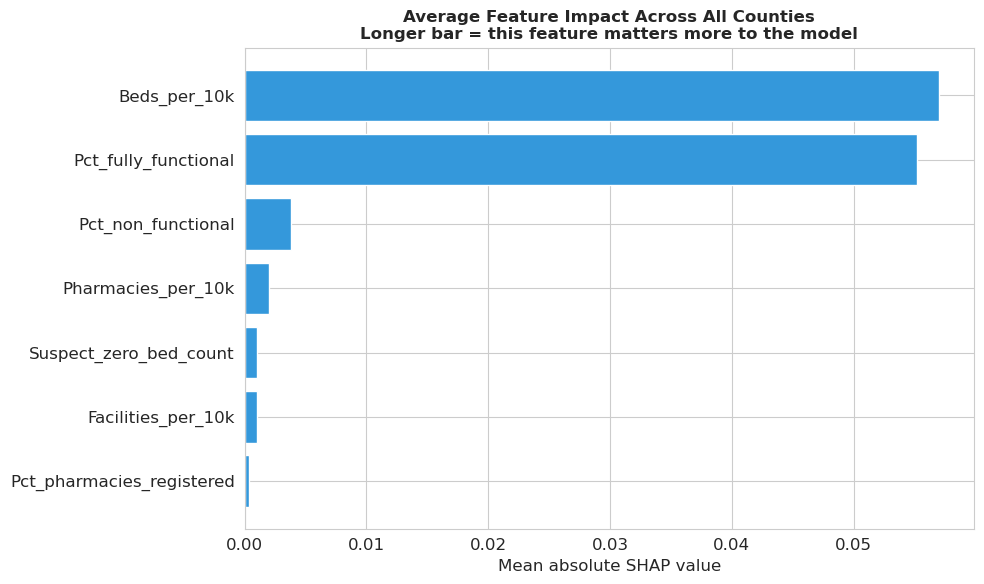

In [19]:
mean_abs_shap = pd.DataFrame({
    'Feature':     features,
    'Mean_impact': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_impact', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    mean_abs_shap['Feature'],
    mean_abs_shap['Mean_impact'],
    color='#3498db',
    edgecolor='white'
)
plt.title('Average Feature Impact Across All Counties\n'
          'Longer bar = this feature matters more to the model',
          fontsize=12, fontweight='bold')
plt.xlabel('Mean absolute SHAP value')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_bar.png', dpi=150)
plt.show()

In [24]:
most_overestimated = df.sort_values('Residual').head(5)['County'].tolist()
 
print('SHAP values for the 5 most overestimated counties:')
print('Negative = feature pushed score DOWN, Positive = pushed score UP')
print()
 
for county in most_overestimated:
    idx      = master[master['County'] == county].index[0]
    shap_row = pd.Series(shap_values[idx], index=features).sort_values()
    print(f'--- {county.title()} ---')
    print(shap_row.round(4).to_string())
    print()

SHAP values for the 5 most overestimated counties:
Negative = feature pushed score DOWN, Positive = pushed score UP

--- Machakos ---
Pct_fully_functional        -0.0859
Suspect_zero_bed_count      -0.0024
Pct_non_functional          -0.0015
Pharmacies_per_10k          -0.0009
Facilities_per_10k          -0.0008
Pct_pharmacies_registered   -0.0000
Beds_per_10k                 0.0074

--- Meru ---
Pct_fully_functional        -0.0682
Beds_per_10k                -0.0259
Suspect_zero_bed_count      -0.0017
Pharmacies_per_10k          -0.0013
Pct_pharmacies_registered   -0.0004
Facilities_per_10k           0.0004
Pct_non_functional           0.0021

--- Bomet ---
Pct_fully_functional        -0.0696
Beds_per_10k                -0.0637
Facilities_per_10k          -0.0020
Pharmacies_per_10k          -0.0008
Pct_pharmacies_registered   -0.0003
Suspect_zero_bed_count      -0.0003
Pct_non_functional           0.0030

--- Makueni ---
Pct_fully_functional        -0.0777
Beds_per_10k                

In [25]:
shap_df = pd.DataFrame(shap_values, columns=features)
shap_df.insert(0, 'County', master['County'].values)
shap_df.to_csv('../data/processed/shap_values.csv', index=False)
 
fairness_output = df[[
    'County', 'Region', 'Score_tier', 'Population',
    'Infrastructure_score', 'Predicted', 'Residual', 'Direction'
]].copy()
fairness_output.to_csv('../data/processed/fairness_audit.csv', index=False)

region_fairness.to_csv('../outputs/reports/fairness_by_region.csv', index=False)
tier_fairness.to_csv('../outputs/reports/fairness_by_tier.csv', index=False)